In [4]:
!pip install emcee corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.9 MB/s eta 0:00:00


In [20]:
#Gerekli kütüphaneleri import ettik
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import pandas as pd

In [7]:
true_mu=150.0   #gerçek parlaklık
true_sigma=10.0  #gözlem hatası
n_obs=50   #gözlem sayısı

In [9]:
np.random.seed(42)
data=true_mu+true_sigma*np.random.randn(n_obs)

Log_Likelihood Hesaplaması

In [25]:
def log_likelihood(theta,data):
  mu,sigma=theta
  if sigma<=0:
    return -np.inf
  return -0.5*np.sum(((data-mu)/sigma)**2+np.log(2*np.pi*sigma**2))

Log_Pior (Ön Bilgi) Hesaplaması

In [26]:
def log_prior(theta):
  mu,sigma=theta
  if 0 < mu < 300 and 0 < sigma < 50:
        return 0.0
  return -np.inf

Log_Probability (veriye göre olasılık)Hesaplaması

In [27]:
def log_probability(theta, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

 MCMC ÖRNEKLEYİCİYİ ÇALIŞTIRMA

In [14]:

initial = [140, 5]  # Başlangıç tahmini
n_walkers = 32
ndim = 2

In [15]:
# Başlangıç konumlarına küçük rastgele gürültü ekleyerek dağıtıyoruz
pos = initial + 1e-4 * np.random.randn(n_walkers, ndim)
sampler = emcee.EnsembleSampler(n_walkers, ndim, log_probability, args=(data,))
sampler.run_mcmc(pos, 2000, progress=True)

100%|██████████| 2000/2000 [00:02<00:00, 836.73it/s]


State([[146.59998341  10.42092649]
 [145.76650675  11.60857143]
 [146.31910041   9.14490759]
 [145.90858789   9.51951477]
 [149.50001792  10.6971051 ]
 [148.23997762   7.57732972]
 [145.92371546   9.17289208]
 [148.26406017  10.31640188]
 [148.47276681   9.17008242]
 [147.57449242  10.21570077]
 [150.23734833   9.44225594]
 [147.03952781   9.89079477]
 [149.14711346  11.12816338]
 [148.27233147   9.8407065 ]
 [148.62613862   9.28586118]
 [145.98667835  10.18979161]
 [145.24739774  10.44528554]
 [149.43608698   9.22811801]
 [146.40245485   8.43770594]
 [145.78330318  10.51884913]
 [147.85401389   8.45182821]
 [147.42844684   9.44192722]
 [149.10109886   8.90341593]
 [146.47069205  10.31726797]
 [147.33120777   8.41840442]
 [148.72370404   8.55018824]
 [147.63410866   8.90291161]
 [147.9781292   10.78401907]
 [148.89230751   8.80346579]
 [147.55857922  11.08242989]
 [149.9933675    9.75677827]
 [147.16186895   9.84247395]], log_prob=[-183.10672788 -185.10921796 -182.75317262 -183.1127120

In [16]:
#SONUÇLARIN TOPLANMASI (Burn-in atılıyor)
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10210/1430967802.py:4: SyntaxWarning: invalid escape sequence '\m'
  labels=["$\mu$ (Parlaklık)", "$\sigma$ (Hata)"],
/tmp/ipykernel_10210/1430967802.py:4: SyntaxWarning: invalid escape sequence '\s'
  labels=["$\mu$ (Parlaklık)", "$\sigma$ (Hata)"],


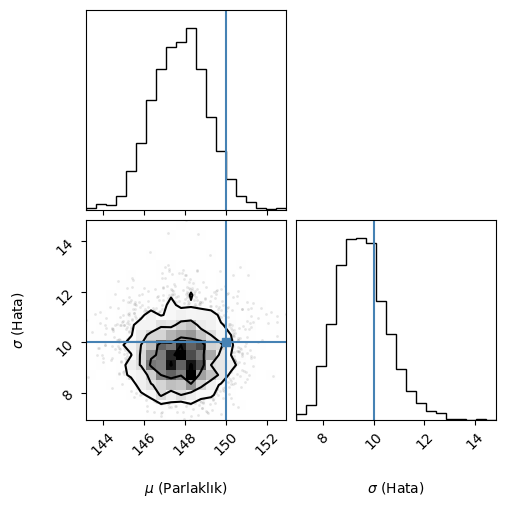

In [17]:
# GÖRSELLEŞTİRME (Corner Plot)
fig = corner.corner(
    flat_samples,
    labels=["$\mu$ (Parlaklık)", "$\sigma$ (Hata)"],
    truths=[true_mu, true_sigma] # Gerçek değerleri mavi çizgiyle gösterir
)
plt.show()

In [18]:
 #İSTATİSTİKLERİ HESAPLAMA
for i, name in enumerate(["mu", "sigma"]):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{name} tahmini: {mcmc[1]:.2f} (+{q[1]:.2f}, -{q[0]:.2f})")

mu tahmini: 147.79 (+1.29, -1.36)
sigma tahmini: 9.49 (+1.04, -0.94)


Tablo Versiyonu

In [28]:
results = []

labels = ["μ (Parlaklık)", "σ (Hata Payı)"]
true_values = [true_mu, true_sigma]

for i, name in enumerate(labels):
    # %16 - %50 - %84 yüzdelikleri
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])

    lower = mcmc[0]      # Alt sınır (%16)
    median = mcmc[1]     # Median (%50)
    upper = mcmc[2]      # Üst sınır (%84)

    true_value = true_values[i]

    # Mutlak hata hesabı
    absolute_error = abs(true_value - median)

    results.append([
        name,
        round(true_value, 2),
        round(median, 2),
        round(lower, 2),
        round(upper, 2),
        round(absolute_error, 2)
    ])

# DataFrame oluşturma
df = pd.DataFrame(
    results,
    columns=[
        "Değişken",
        "Gerçek Değer (Girdi)",
        "Tahmin Edilen (Median)",
        "Alt Sınır (%16)",
        "Üst Sınır (%84)",
        "Mutlak Hata"
    ]
)

# Güzel tablo çıktısı
print("\n")
print("=" * 95)
print("PARAMETRE KARŞILAŞTIRMA TABLOSU")
print("=" * 95)
print(df.to_string(index=False))
print("=" * 95)
print("\n")



PARAMETRE KARŞILAŞTIRMA TABLOSU
     Değişken  Gerçek Değer (Girdi)  Tahmin Edilen (Median)  Alt Sınır (%16)  Üst Sınır (%84)  Mutlak Hata
μ (Parlaklık)                 150.0                  147.79           146.43           149.07         2.21
σ (Hata Payı)                  10.0                    9.49             8.55            10.53         0.51




Gözlem Sayısı ve Ön Bilgi Değiştirme Durumuna Göre Sonuçlar

In [24]:
# ==========================================================
# EK ANALİZ 1 → Gözlem Sayısını Değiştirme (n_obs = 100)
# ==========================================================

print("\n" + "=" * 80)
print("EK ANALİZ 1 : n_obs = 100 DURUMU")
print("=" * 80)

# Yeni gözlem sayısı
n_obs_new = 100

# Yeni sentetik veri üretimi
data_new = true_mu + true_sigma * np.random.randn(n_obs_new)

# Yeni sampler çalıştırma
sampler_new = emcee.EnsembleSampler(
    n_walkers,
    ndim,
    log_probability,
    args=(data_new,)
)

sampler_new.run_mcmc(pos, 2000, progress=True)

# Sonuçları toplama
flat_samples_new = sampler_new.get_chain(
    discard=500,
    thin=15,
    flat=True
)

# İstatistikleri yazdırma
for i, name in enumerate(["mu", "sigma"]):
    mcmc = np.percentile(flat_samples_new[:, i], [16, 50, 84])

    print(f"\n{name} için sonuçlar (n_obs = 100):")
    print(f"Alt sınır (%16): {mcmc[0]:.2f}")
    print(f"Median (%50):    {mcmc[1]:.2f}")
    print(f"Üst sınır (%84): {mcmc[2]:.2f}")

print("\nYorum:")
print("Gözlem sayısı arttığında posterior dağılım daralır.")
print("Yani belirsizlik azalır ve tahmin gerçek değere daha çok yaklaşır.")


# ==========================================================
# EK ANALİZ 2 → Prior Aralığını Daraltma
# örnek: 100 < mu < 110
# ==========================================================

print("\n" + "=" * 80)
print("EK ANALİZ 2 : DAR PRIOR DURUMU")
print("=" * 80)


# Yeni prior fonksiyonu
def log_prior_narrow(theta):
    mu, sigma = theta

    # Dar prior
    if 100 < mu < 110 and 0 < sigma < 50:
        return 0.0

    return -np.inf


# Yeni posterior fonksiyonu
def log_probability_narrow(theta, data):
    lp = log_prior_narrow(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, data)


# Yeni sampler
sampler_narrow = emcee.EnsembleSampler(
    n_walkers,
    ndim,
    log_probability_narrow,
    args=(data,)
)

sampler_narrow.run_mcmc(pos, 2000, progress=True)

flat_samples_narrow = sampler_narrow.get_chain(
    discard=500,
    thin=15,
    flat=True
)

# Sonuçları yazdırma
for i, name in enumerate(["mu", "sigma"]):
    mcmc = np.percentile(flat_samples_narrow[:, i], [16, 50, 84])

    print(f"\n{name} için sonuçlar (Dar Prior):")
    print(f"Alt sınır (%16): {mcmc[0]:.2f}")
    print(f"Median (%50):    {mcmc[1]:.2f}")
    print(f"Üst sınır (%84): {mcmc[2]:.2f}")

print("\nYorum:")
print("Prior çok dar seçildiğinde model veriden çok prior bilgisini takip eder.")
print("Bu nedenle true_mu = 150 olmasına rağmen sonuç 100–110 aralığına zorlanır.")
print("Yanlış prior seçimi posterior sonucu bozabilir.")


EK ANALİZ 1 : n_obs = 100 DURUMU


100%|██████████| 2000/2000 [00:02<00:00, 827.01it/s]



mu için sonuçlar (n_obs = 100):
Alt sınır (%16): 149.08
Median (%50):    150.04
Üst sınır (%84): 151.04

sigma için sonuçlar (n_obs = 100):
Alt sınır (%16): 9.41
Median (%50):    10.11
Üst sınır (%84): 10.87

Yorum:
Gözlem sayısı arttığında posterior dağılım daralır.
Yani belirsizlik azalır ve tahmin gerçek değere daha çok yaklaşır.

EK ANALİZ 2 : DAR PRIOR DURUMU


  0%|          | 0/2000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [00:01<00:00, 1314.10it/s]


mu için sonuçlar (Dar Prior):
Alt sınır (%16): 140.00
Median (%50):    140.00
Üst sınır (%84): 140.00

sigma için sonuçlar (Dar Prior):
Alt sınır (%16): 5.00
Median (%50):    5.00
Üst sınır (%84): 5.00

Yorum:
Prior çok dar seçildiğinde model veriden çok prior bilgisini takip eder.
Bu nedenle true_mu = 150 olmasına rağmen sonuç 100–110 aralığına zorlanır.
Yanlış prior seçimi posterior sonucu bozabilir.
